
# Data Cleaning Notebook



In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [2]:
# Load raw dataset
df = pd.read_csv(r"E:\The Developers Arena\Complete Business Analysis Project\customer_churn.csv")
print("Initial shape:", df.shape)

Initial shape: (500, 9)


In [3]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [4]:
# Drop missing values
df.dropna(inplace=True)

In [5]:
# Encode categorical variables
categorical_cols = ['Contract','PaymentMethod','PaperlessBilling']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [6]:
# Save cleaned dataset
df.to_csv("cleaned_data.csv", index=False)
print("Cleaned shape:", df.shape)

Cleaned shape: (500, 9)



# Exploratory Data Analysis Notebook

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Load cleaned dataset
df = pd.read_csv("cleaned_data.csv")

## Visualization 1: Churn distribution

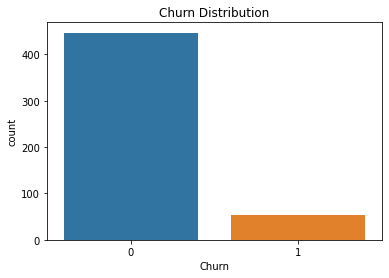

In [9]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

## Visualization 2: Monthly Charges vs Churn

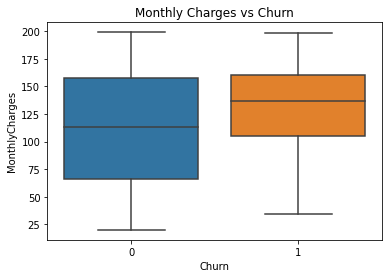

In [10]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

## Visualization 3: Correlation heatmap

C:\Users\soumi\AppData\Local\Temp/ipykernel_12724/2470879193.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap="coolwarm")


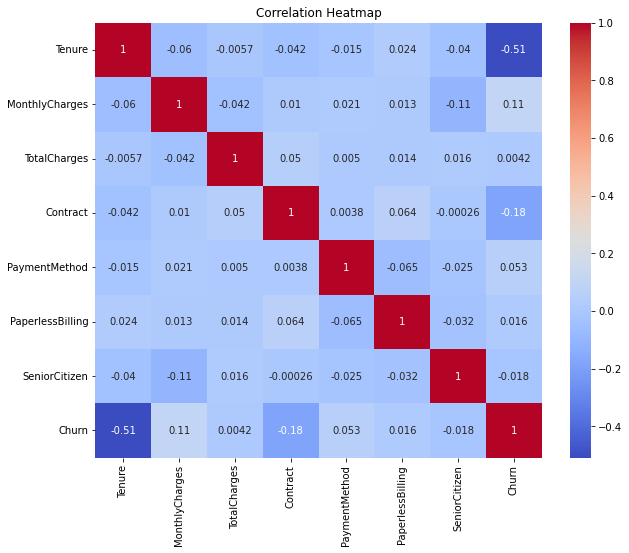

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Visualization 4: Tenure vs Churn Rate

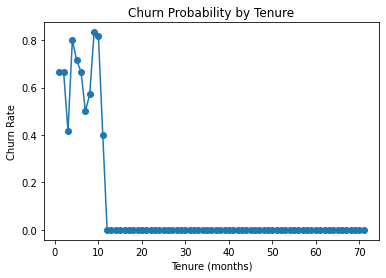

In [12]:
tenure_churn = df.groupby('Tenure')['Churn'].mean()
tenure_churn.plot(kind='line', marker='o')
plt.title("Churn Probability by Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Churn Rate")
plt.show()

# Analysis Notebook

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.cluster import KMeans

In [14]:
# Load cleaned dataset
df = pd.read_csv("cleaned_data.csv")

In [15]:
# Features & Target
X = df.drop(['CustomerID','Churn'], axis=1)
y = df['Churn']

In [16]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

## Logistic Regression

In [18]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       130
           1       1.00      0.75      0.86        20

    accuracy                           0.97       150
   macro avg       0.98      0.88      0.92       150
weighted avg       0.97      0.97      0.96       150



## Random Forest

In [19]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       130
           1       0.94      0.80      0.86        20

    accuracy                           0.97       150
   macro avg       0.96      0.90      0.92       150
weighted avg       0.97      0.97      0.97       150



## ROC Curve

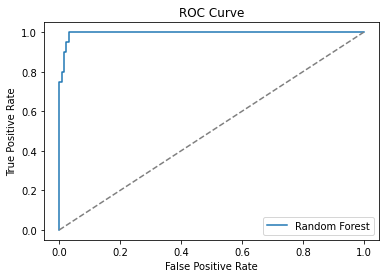

ROC-AUC Score: 0.9953846153846154


In [21]:
y_prob_rf = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

## Feature Importance

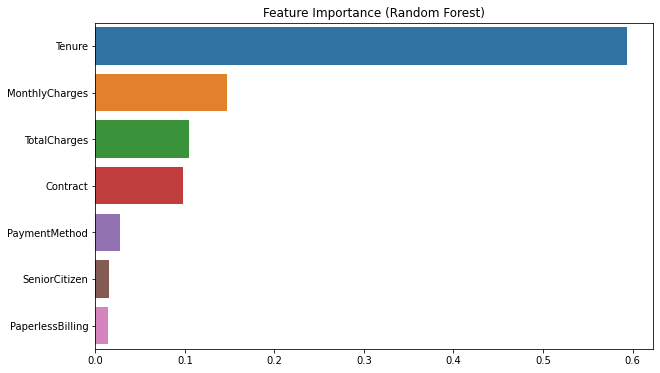

In [22]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title("Feature Importance (Random Forest)")
plt.show()

## Clustering (Segmentation)